### [Machine Learning for Quants](https://wire.insiderfinance.io/machine-learning-for-quants-series-with-python-part-1-8e7980bf7458)

> Machine Learning for Quants (Part 1)

In [1]:
!pip install -qq yfinance

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('fivethirtyeight')

#### **Setup and Data Acquisition**

In [3]:
# Download historical data for SPY
# We use a long window to ensure enough data points
df = yf.download('SPY', start='2013-01-01', end='2026-01-01', progress=False)

# Calculate daily returns
df['Return'] = df['Close'].pct_change()

# Drop NaN values created by pct_change
df.dropna(inplace=True)

print(f"Data Loaded: {len(df)} days of trading data.")
display(df.head())

Data Loaded: 3269 days of trading data.


Price,Close,High,Low,Open,Volume,Return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2013-01-03,116.3459,116.8568,116.0345,116.5534,144761800,-0.0023
2013-01-04,116.8568,117.0484,116.2979,116.5375,116817700,0.0044
2013-01-07,116.5375,116.6492,116.1064,116.4417,110002500,-0.0027
2013-01-08,116.2021,116.4895,115.7470,116.3299,121265100,-0.0029
2013-01-09,116.4975,116.8169,116.2740,116.4576,90745600,0.0025


#### **Feature Engineering (The Momentum Signal)**

In [4]:
# Create lag features (signals)
# We want to use the returns of the past 5 days to predict today's return
lags = 5

for i in range(1, lags + 1):
    df[f'Lag_{i}'] = df['Return'].shift(i)

# Drop the NaN values created by shifting
df.dropna(inplace=True)

# Define Features (X) and Target (y)
feature_cols = [f'Lag_{i}' for i in range(1, lags + 1)]
X = df[feature_cols]
y = df['Return']

print("Feature Matrix X (First 5 rows):")
display(X.head())

Feature Matrix X (First 5 rows):


Price,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5
Ticker,,,,,
Date,,,,,
2013-01-10,0.0025,-0.0029,-0.0027,0.0044,-0.0023
2013-01-11,0.0079,0.0025,-0.0029,-0.0027,0.0044
2013-01-14,-0.0001,0.0079,0.0025,-0.0029,-0.0027
2013-01-15,-0.0007,-0.0001,0.0079,0.0025,-0.0029
2013-01-16,0.0007,-0.0007,-0.0001,0.0079,0.0025


#### **Splitting the Dataset**

In [5]:
# Split into Training (80%) and Testing (20%) sets
# shuffle=False is CRITICAL for time series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 2611
Testing set size: 653


#### **Training the Linear Regression Model**

In [6]:
# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# View learned coefficients (The "Theta" values)
print("Intercept (Bias):", lr_model.intercept_)
print("Coefficients (Weights):", lr_model.coef_)
print("Score: ", lr_model.score(X_train, y_train))

Intercept (Bias): 0.0005926975082638934
Coefficients (Weights): [-0.1187  0.0535 -0.0077 -0.0684  0.0222]
Score:  0.02388732829061002


#### **Evaluation and Visualizing Performance**

Mean Squared Error (Linear Model): 0.00009265


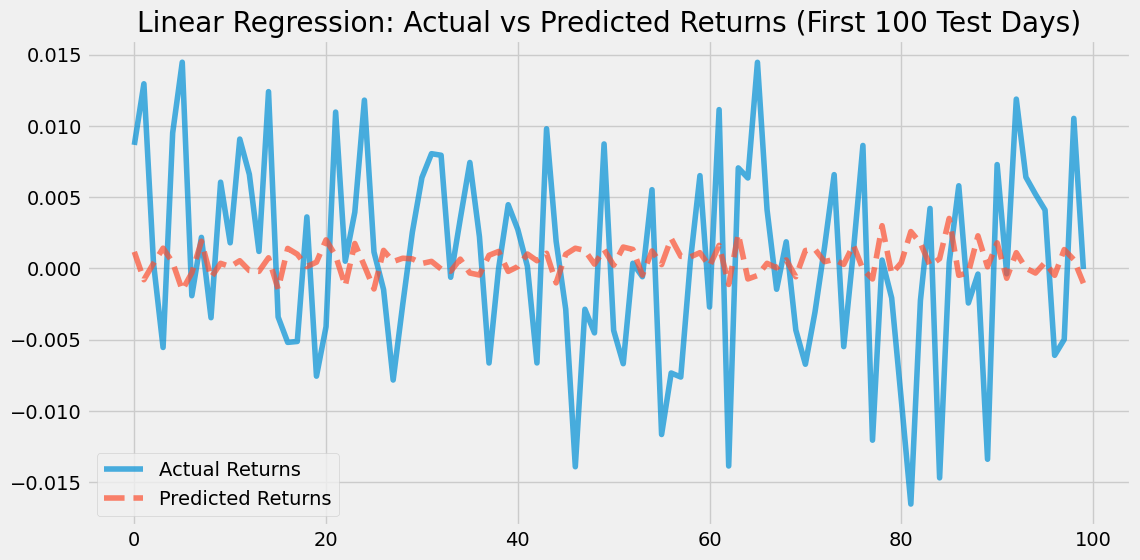

In [7]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (Linear Model): {mse:.8f}")

# Visualization: Predicted vs Actual (Subset for clarity)
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual Returns', alpha=0.7)
plt.plot(y_pred[:100], label='Predicted Returns', alpha=0.7, linestyle='--')
plt.title('Linear Regression: Actual vs Predicted Returns (First 100 Test Days)')
plt.legend()
plt.show()

#### **Forcing Overfitting (Polynomial Features)**

In [8]:
# Create polynomial features (degree 4 - highly complex)
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train a new model on this complex data
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict on Train and Test
y_train_pred_poly = poly_model.predict(X_train_poly)
y_test_pred_poly = poly_model.predict(X_test_poly)

# Calculate Errors
train_mse = mean_squared_error(y_train, y_train_pred_poly)
test_mse = mean_squared_error(y_test, y_test_pred_poly)

print(f"Training MSE (Poly Model): {train_mse:.8f}")
print(f"Testing MSE (Poly Model):  {test_mse:.8f}")

Training MSE (Poly Model): 0.00008087
Testing MSE (Poly Model):  0.00112162


### [Master Regularization: Ridge, Lasso & ElasticNet](https://medium.com/@simplifiedzone/master-regularization-ridge-lasso-elasticnet-explained-3290d06c9700)

> Machine Learning for Quants (Part 2)

#### **Data Preparation (Recap)**

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

# 1. Fetch Data
df = yf.download('SPY', start='2010-01-01', end='2026-01-01')
df['Return'] = df['Close'].pct_change()
df.dropna(inplace=True)

display(df.sample(10))

# 2. Engineer More Features (Lags 1 through 10)
# More features = higher risk of overfitting = better test for Regularization
lags = 10
feature_cols = []
for i in range(1, lags + 1):
    col_name = f'Lag_{i}'
    df[col_name] = df['Return'].shift(i)
    feature_cols.append(col_name)

df.dropna(inplace=True)

X = df[feature_cols]
y = df['Return']

# 3. Split Data (Chronological Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training Features: {X_train.shape[1]} inputs (Lags 1-10)")

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2016-10-31,182.9345,183.4853,182.7710,183.2615,61272500,0.0000
2014-10-16,153.8301,154.9120,151.0388,151.1792,270391000,-0.0009
2020-10-27,314.3802,316.1463,314.1665,315.8117,65994100,-0.0034
2017-09-14,218.5149,218.7159,218.0868,218.2616,95446300,-0.0003
2014-11-17,168.7779,168.9513,168.1833,168.3485,80441000,0.0006
2011-11-07,97.9935,98.0943,96.3946,97.3182,196617200,0.0062
2024-03-15,499.0763,500.9069,497.4024,499.4483,107646300,-0.0069
2012-03-13,109.3934,109.4481,107.8547,108.0344,184090500,0.0180


Training Features: 10 inputs (Lags 1-10)


#### **Ridge Regression (Manual Tuning)**

In [10]:
# Initialize Ridge with a specific alpha (regularization strength)
# Alpha = 1.0 is a standard starting point
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge MSE (alpha=1.0): {mse_ridge:.8f}")
print("Ridge Coefficients:", ridge_model.coef_)

Ridge MSE (alpha=1.0): 0.00010103
Ridge Coefficients: [-0.0291  0.0176 -0.0074 -0.0123 -0.0034 -0.0214  0.0295 -0.0252  0.0212
 -0.0039]


#### **Lasso Regression (Feature Selection)**

In [11]:
# Initialize Lasso
# We assume a small alpha because returns are small numbers
lasso_model = Lasso(alpha=0.0001)
lasso_model.fit(X_train, y_train)

# Check Coefficients
print("\nLasso Coefficients:")
for feature, coef in zip(feature_cols, lasso_model.coef_):
    print(f"{feature}: {coef:.6f}")

# Count non-zero features
n_selected = np.sum(lasso_model.coef_ != 0)
print(f"\nLasso selected {n_selected} out of {lags} features.")


Lasso Coefficients:
Lag_1: -0.000000
Lag_2: 0.000000
Lag_3: -0.000000
Lag_4: -0.000000
Lag_5: -0.000000
Lag_6: -0.000000
Lag_7: 0.000000
Lag_8: -0.000000
Lag_9: 0.000000
Lag_10: -0.000000

Lasso selected 0 out of 10 features.


#### **Hyperparameter Tuning with Grid Search**

In [12]:
# Define the TimeSeriesSplit (Cross-Validation compatible with time)
# This splits training data into expanding windows
tscv = TimeSeriesSplit(n_splits=5)

# Define the model
elastic = ElasticNet()

# Define the grid of parameters to test
# alpha: strength of regulation
# l1_ratio: mix between Lasso (1.0) and Ridge (0.0)
param_grid = {
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.1, 0.5, 0.9]
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Fit on Training Data (GridSearch handles the internal validation splits)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Internal Score (Negative MSE): {grid_search.best_score_}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'alpha': 0.0001, 'l1_ratio': 0.1}
Best Internal Score (Negative MSE): -0.00011420300447905046


#### **Final Evaluation**

Final Optimized ElasticNet MSE: 0.00010107


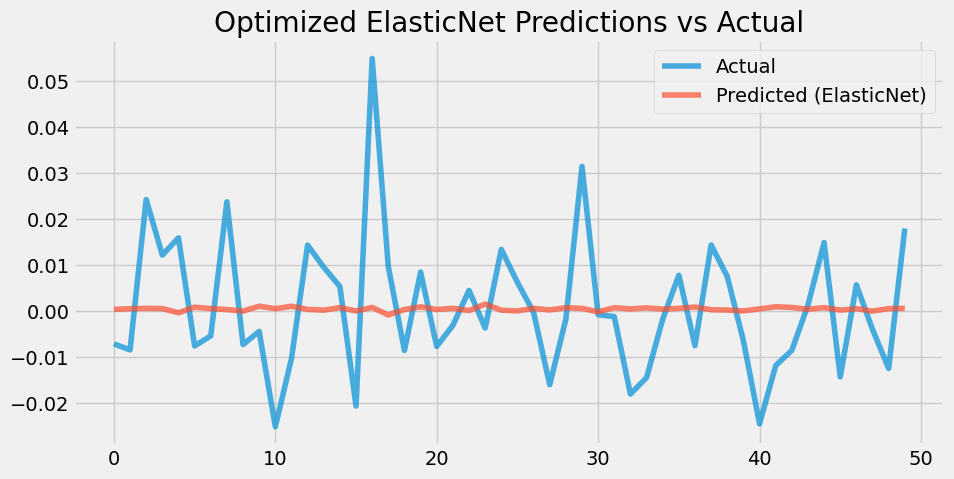

In [13]:
# Get the best model
best_model = grid_search.best_estimator_

# Predict on Test Set
y_pred_best = best_model.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred_best)

print(f"Final Optimized ElasticNet MSE: {final_mse:.8f}")

# Visualization check
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Actual', alpha=0.7)
plt.plot(y_pred_best[:50], label='Predicted (ElasticNet)', alpha=0.7)
plt.legend()
plt.title("Optimized ElasticNet Predictions vs Actual")
plt.show()

### [Mastering Classification in Trading with Logistic Regression](https://medium.com/@simplifiedzone/mastering-classification-in-trading-with-logistic-regression-9dd12a05fb70)

> Machine Learning for Quants (Part 3)

#### **Data Setup and Binary Target**

In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fetch Data
df = yf.download('SPY', start='2010-01-01', end='2026-01-01')
df['Return'] = df['Close'].pct_change()
df.dropna(inplace=True)

# 2. Create Binary Target
# If Return > 0, Class is 1 (Up). Otherwise 0 (Down).
df['Direction'] = np.where(df['Return'] > 0, 1, 0)

# 3. Create Lagged Features (Lags 1-5)
lags = 5
feature_cols = []
for i in range(1, lags + 1):
    col_name = f'Lag_{i}'
    df[col_name] = df['Return'].shift(i)
    feature_cols.append(col_name)

df.dropna(inplace=True)
display(df.sample(10))

# Define X (Features) and y (Target)
X = df[feature_cols]
y = df['Direction']  # Note: Target is now 'Direction', not 'Return'

print("Class Distribution:")
display(y.value_counts(normalize=True))

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Return,Direction,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,,
Date,,,,,,,,,,,,
2021-03-24,362.9256,367.8236,362.8788,366.1847,97588600,-0.0051,0,-0.0079,0.0080,-0.0019,-0.0145,0.0034
2025-07-11,620.0637,621.2966,617.9856,619.1887,63670200,-0.0035,0,0.0028,0.0060,-0.0005,-0.0075,0.0079
2024-04-30,491.3920,498.8121,491.3920,497.8332,77483600,-0.0158,0,0.0035,0.0095,-0.0038,-0.0005,0.0119
2022-12-01,389.8102,392.3172,387.2937,391.1403,76398200,-0.0007,0,0.0315,-0.0017,-0.0160,-0.0002,0.0063
2011-07-27,100.8401,102.4075,100.7088,102.3766,249020100,-0.0205,0,-0.0037,-0.0056,0.0007,0.0139,-0.0006
2012-03-23,109.5511,109.6766,108.6882,109.2923,120521000,0.0032,1,-0.0072,-0.0016,-0.0029,0.0039,0.0014
2020-07-17,297.8510,298.6379,296.0178,297.9991,62774900,0.0029,1,-0.0033,0.0092,0.0130,-0.0087,0.0102
2013-02-11,121.1680,121.2718,120.8646,121.1440,73775000,-0.0002,0,0.0056,-0.0013,0.0007,0.0101,-0.0112


Class Distribution:


,proportion
Direction,
1,0.5535
0,0.4465


#### **Splitting and Scaling**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split Data (Chronological)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 2. Initialize Scaler
scaler = StandardScaler()

# 3. Fit on Train, Transform Train
X_train_scaled = scaler.fit_transform(X_train)

# 4. Transform Test (Do NOT fit on test!)
X_test_scaled = scaler.transform(X_test)

print("First 5 Scaled Train Rows:\n", X_train_scaled[:5])

First 5 Scaled Train Rows:
 [[ 0.0821  0.2567  0.3387  0.0192  0.1953]
 [-0.8903  0.0814  0.2575  0.3386  0.0189]
 [ 0.7214 -0.8916  0.0821  0.2574  0.3383]
 [ 0.2008  0.7212 -0.8917  0.082   0.2572]
 [-1.0624  0.2002  0.7224 -0.8919  0.0818]]


#### **Training Logistic Regression**

In [16]:
from sklearn.linear_model import LogisticRegression

# Initialize and Train
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Predict Classes (0 or 1)
y_pred = log_model.predict(X_test_scaled)

# Predict Probabilities (0.0 to 1.0)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1] # Probability of Class 1

score = log_model.score(X_test_scaled, y_test)
print(f"Accuracy: {score:.4f}")
print("Predictions generated.")

Accuracy: 0.5634
Predictions generated.


#### **The Confusion Matrix**

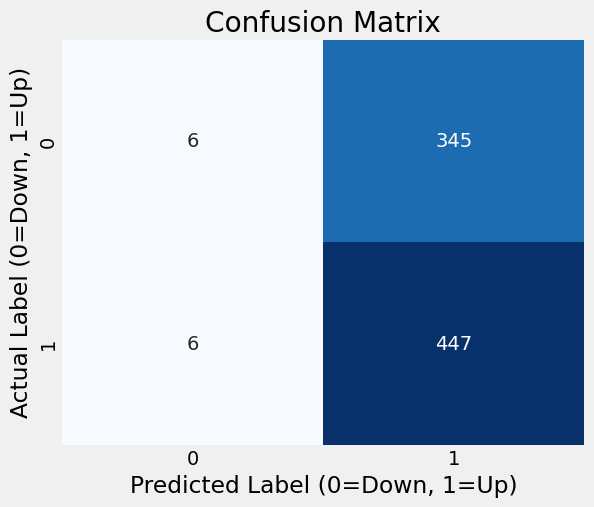

Model Accuracy: 0.5634


In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label (0=Down, 1=Up)')
plt.ylabel('Actual Label (0=Down, 1=Up)')
plt.title('Confusion Matrix')
plt.show()

# Simple Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.4f}")

#### **Advanced Metrics (Precision & Recall)**

In [18]:
from sklearn.metrics import classification_report

display(classification_report(y_test, y_pred))

'              precision    recall  f1-score   support\n\n           0       0.50      0.02      0.03       351\n           1       0.56      0.99      0.72       453\n\n    accuracy                           0.56       804\n   macro avg       0.53      0.50      0.38       804\nweighted avg       0.54      0.56      0.42       804\n'

#### **The Receiver Operating Characteristic (ROC) Curve**

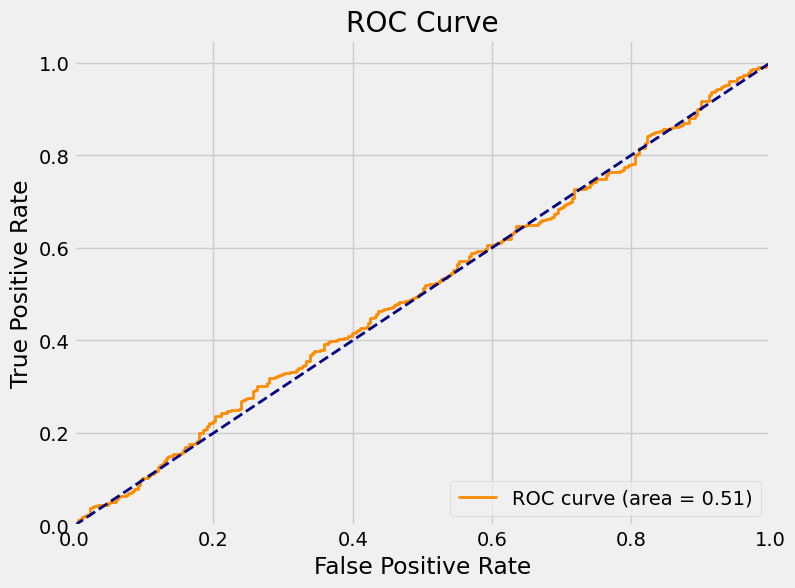

In [19]:
from sklearn.metrics import roc_curve, auc

# Calculate rates
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random Guess Line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

### [Credit Risk with Machine Learning for Quants](https://wire.insiderfinance.io/mastering-credit-risk-with-machine-learning-for-quants-371777b3ebad)

> Machine Learning for Quants (Part 4)

#### **Generating the Dataset**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

# 1. Generate Synthetic Data
# We create 10,000 samples, 4 features.
# weights=[0.95, 0.05] creates an imbalance (5% defaults)
X, y = make_classification(n_samples=10000, n_features=4, n_informative=3,
                           n_redundant=0, n_clusters_per_class=1,
                           weights=[0.95, 0.05], random_state=42)

# 2. Convert to DataFrame for readability
columns = ['Income', 'Loan_Amount', 'Age_Normalized', 'Credit_Score_Normalized']
df = pd.DataFrame(X, columns=columns)
df['Default'] = y

# 3. Inspect the Imbalance
print("Class Distribution:")
display(df['Default'].value_counts(normalize=True))

print("\nFirst 5 rows:")
display(df.head())

Class Distribution:


,proportion
Default,
0,0.9454
1,0.0546



First 5 rows:


,Income,Loan_Amount,Age_Normalized,Credit_Score_Normalized,Default
0,-0.7863,0.9211,-0.9557,-0.9759,0
1,-0.7385,0.9465,-0.6788,-1.0642,0
2,-2.9367,1.3290,-2.6383,-0.8626,0
3,-2.2418,1.3737,-1.8764,0.5455,0
4,-1.2452,0.7898,-1.6470,0.6667,0


#### **Preprocessing (Split & Scale)**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define Features and Target
X = df.drop('Default', axis=1)
y = df['Default']

# 1. Random Split (Shuffle=True is default, but good to be explicit)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# 2. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (8000, 4)
Test set: (2000, 4)


#### **Baseline Logistic Regression**

Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1894
           1       0.99      0.73      0.84       106

    accuracy                           0.98      2000
   macro avg       0.99      0.86      0.91      2000
weighted avg       0.99      0.98      0.98      2000

Baseline AUC Score: 0.9375


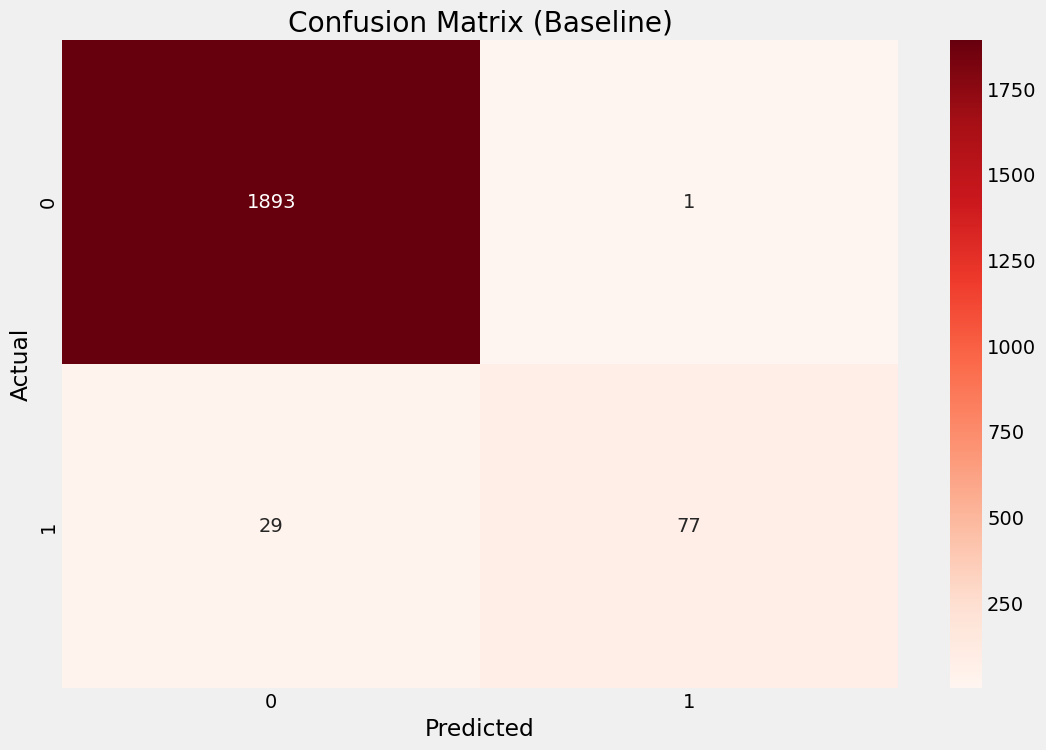

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Initialize Model (Standard)
model_base = LogisticRegression()
model_base.fit(X_train_scaled, y_train)

# Predict
y_pred = model_base.predict(X_test_scaled)
y_prob = model_base.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred))

print(f"Baseline AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Visualizing the Imbalance in Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### **Adding Complexity (Polynomial Features)**

In [23]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Create Polynomial Features (Degree 2)
# This creates interaction terms: Income^2, Income*Age, Age^2, etc.
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"New Feature Count: {X_train_poly.shape[1]} (Original was 4)")

# 2. Train New Model on Complex Data
# We use 'class_weight=balanced' to help the model pay attention to rare defaults
model_poly = LogisticRegression(class_weight='balanced', solver='liblinear')
model_poly.fit(X_train_poly, y_train)

# Predict
y_prob_poly = model_poly.predict_proba(X_test_poly)[:, 1]

print(f"Polynomial Model AUC Score: {roc_auc_score(y_test, y_prob_poly):.4f}")

New Feature Count: 14 (Original was 4)
Polynomial Model AUC Score: 0.9607


#### **Comparing Performance (ROC Curves)**

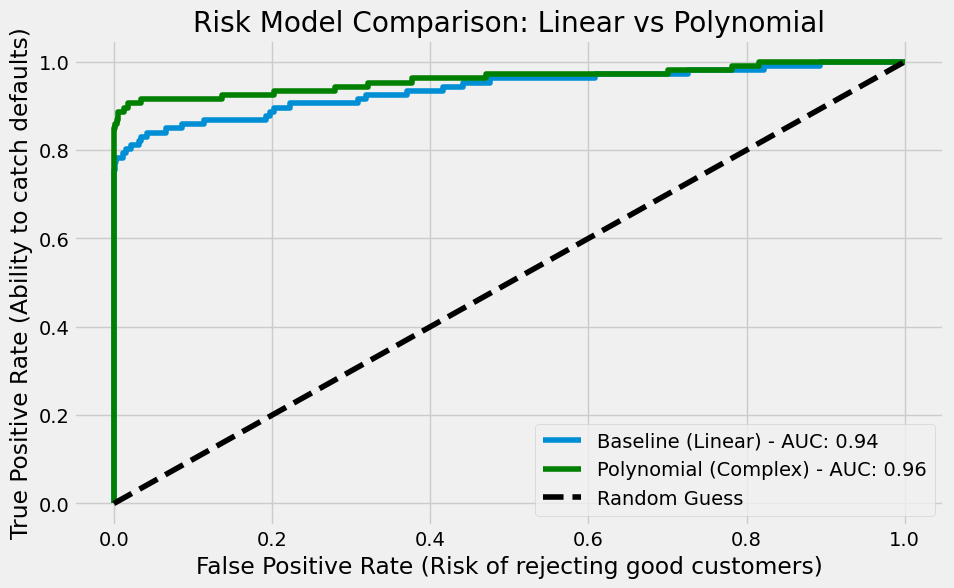

In [24]:
from sklearn.metrics import roc_curve

# Calculate ROC for Baseline
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob)

# Calculate ROC for Polynomial
fpr_poly, tpr_poly, _ = roc_curve(y_test, y_prob_poly)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline (Linear) - AUC: {roc_auc_score(y_test, y_prob):.2f}')
plt.plot(fpr_poly, tpr_poly, label=f'Polynomial (Complex) - AUC: {roc_auc_score(y_test, y_prob_poly):.2f}', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate (Risk of rejecting good customers)')
plt.ylabel('True Positive Rate (Ability to catch defaults)')
plt.title('Risk Model Comparison: Linear vs Polynomial')
plt.legend()
plt.show()